# Quanto bene sono pagati i diversi lavori e le diverse skill?

Metodologia:
1. Valutare la retribuzione mediana per i top 6 lavori più pagati.
2. Trovare la retribuzione mediana per le skill dei Data Analyst.
3. Visualizzare per le retribuzioni più pagate e per le skill più pagate.

In [61]:
# Importare le librerie necessarie
import ast
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from datasets import load_dataset
from typing import cast

# Caricare il dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = cast(pd.DataFrame, dataset['train'].to_pandas())

# Pulire i dati
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

In [62]:
df_US = df[df['job_country'] == 'United States'].dropna(subset=['salary_year_avg'])
job_titles = df_US['job_title_short'].value_counts().index[:6].to_list() # Prendere i top 6 lavori più pagati
df_US_top_6 = df_US[df_US['job_title_short'].isin(job_titles)]
job_order = df_US_top_6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

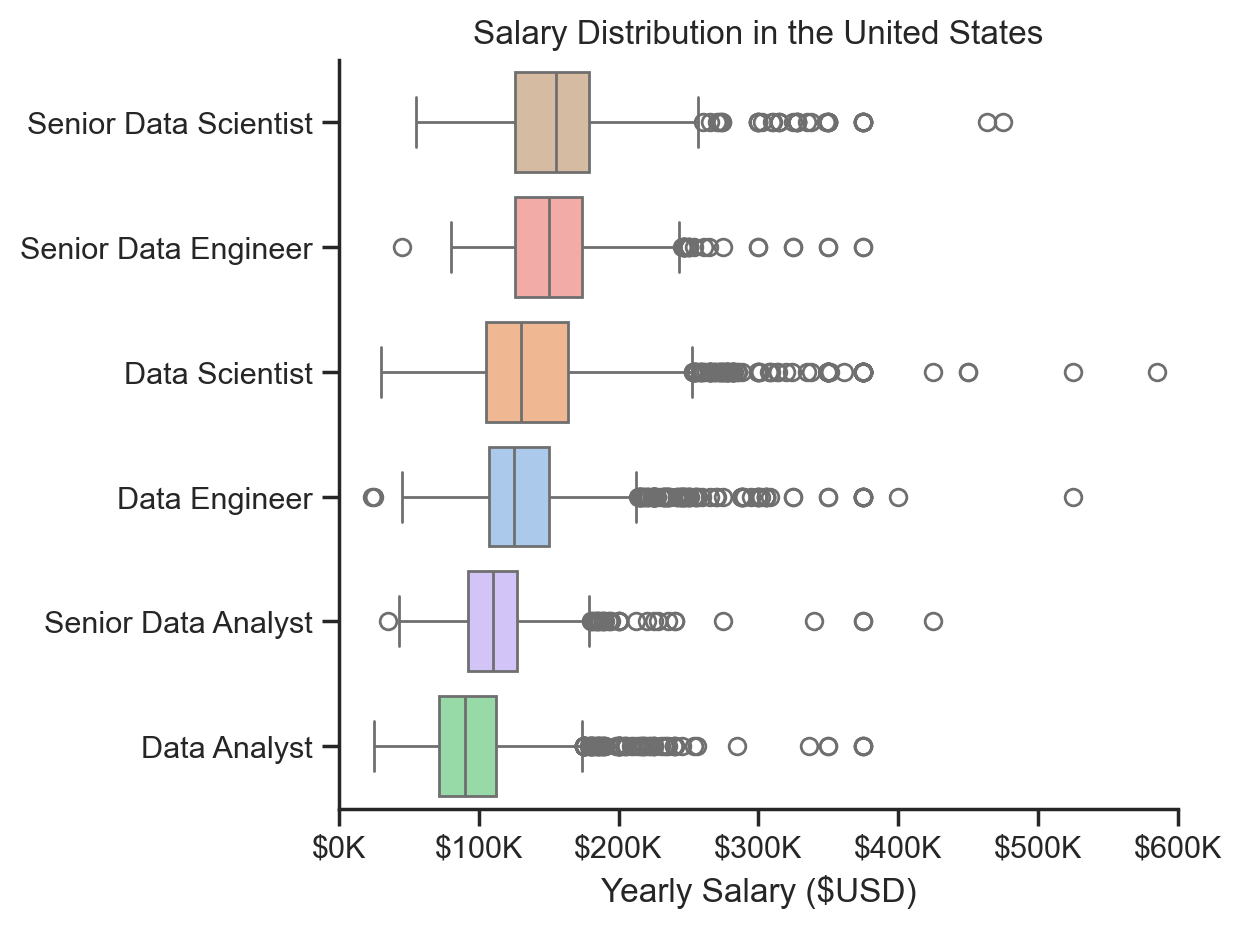

In [82]:
%config InlineBackend.figure_format = 'retina'
import seaborn as sns
sns.set_theme(style="ticks")
sns.boxplot(data=df_US_top_6, x='salary_year_avg', y='job_title_short', palette='pastel', order=job_order, hue = 'job_title_short')
sns.despine() 
plt.title("Salary Distribution in the United States")
plt.xlabel("Yearly Salary ($USD)")
plt.xlim(0, 600_000)
plt.ylabel("")
plt.tight_layout()
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.savefig('images/salary_distribution.svg', format='svg')


## Salario mediano vs skills per i Data Analyst negli USA

In [88]:
df_US_DA = df_US[df_US['job_title_short'] == 'Data Analyst']
df_US_DA = df_US_DA.explode('job_skills')

In [89]:
df_DA_top_pay = df_US_DA.groupby('job_skills')['salary_year_avg'].agg(['median', 'count']).sort_values(by='median', ascending=False).head(10)
df_DA_top_pay

,median,count
job_skills,,
dplyr,196250.0,2
bitbucket,189000.0,3
gitlab,186000.0,3
solidity,179000.0,1
hugging face,175000.0,1
couchbase,160515.0,1
ansible,159640.0,1
mxnet,149000.0,2
cassandra,148250.0,6


In [96]:
df_DA_top_skills = df_US_DA.groupby('job_skills')['salary_year_avg'].agg(['median', 'count']).sort_values(by='count', ascending=False).head(10)
df_DA_top_skills = df_DA_top_skills.sort_values(by='median', ascending=False)
df_DA_top_skills

,median,count
job_skills,,
python,97500.00,1431
tableau,92875.00,1364
r,92500.00,893
sql server,92500.00,286
sql,91000.00,2508
sas,90000.00,926
power bi,90000.00,838
powerpoint,85000.00,462
excel,84392.00,1808


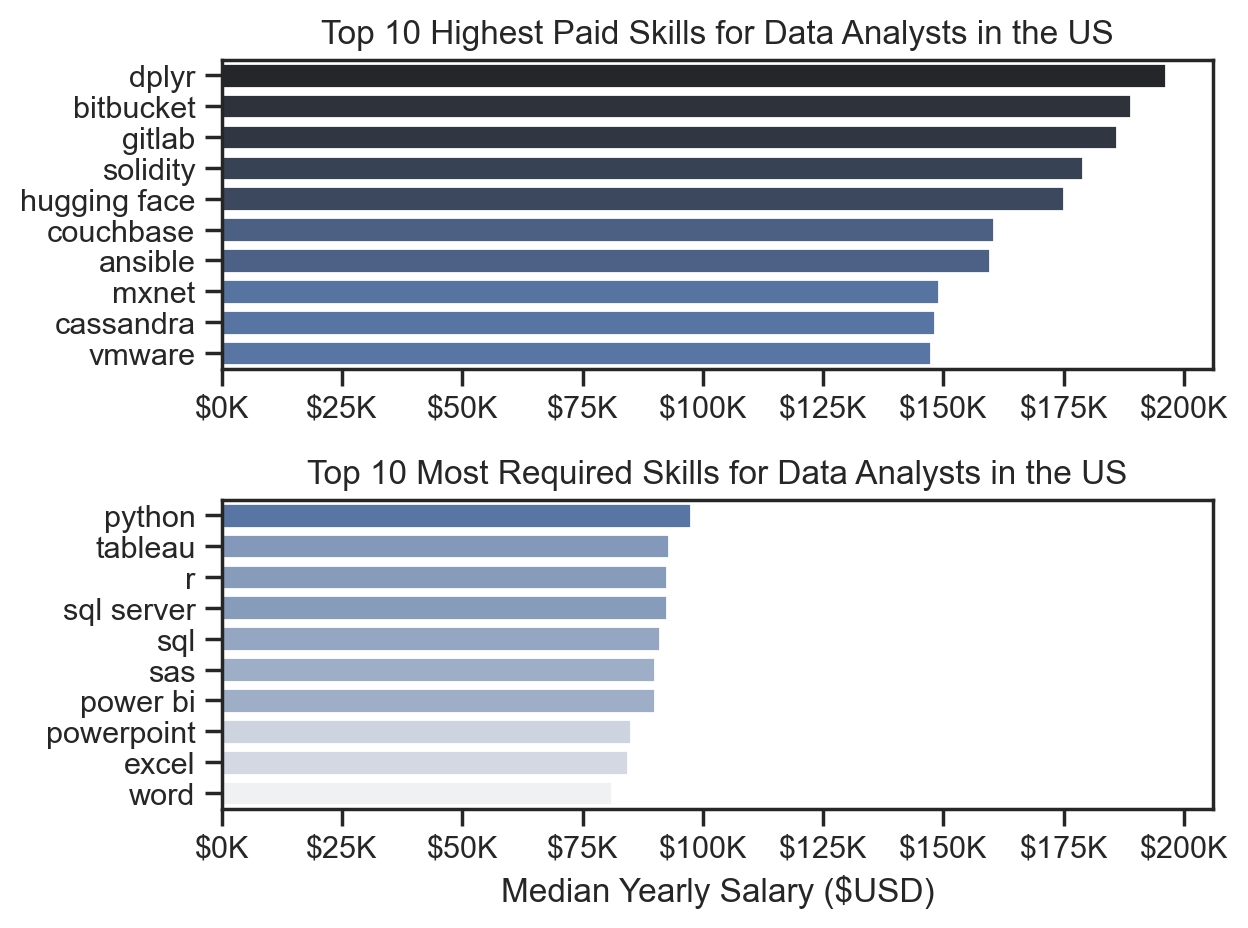

In [99]:
%config InlineBackend.figure_format = 'retina'
fig, axes = plt.subplots(2, 1)
sns.set_theme(style="ticks")

sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=axes[0], hue='median', palette='dark:b_r')
axes[0].set_title("Top 10 Highest Paid Skills for Data Analysts in the US")
axes[0].legend_.remove() # rimuove la legenda
axes[0].set_ylabel("")
axes[0].set_xlabel("")
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K')) # formatta l'asse x per mostrare i salari in migliaia di dollari


sns.barplot(data=df_DA_top_skills, x='median', y=df_DA_top_skills.index, ax=axes[1], hue='median', palette='light:b')
axes[1].set_title("Top 10 Most Required Skills for Data Analysts in the US")
axes[1].legend_.remove() # rimuove la legenda
axes[1].set_ylabel("")
axes[1].set_xlabel("Median Yearly Salary ($USD)")
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K')) # formatta l'asse x per mostrare i salari in migliaia di dollari
axes[1].set_xlim(axes[0].get_xlim()) # allinea l'asse x del secondo grafico a quello del primo
fig.tight_layout()
plt.savefig('images/skills_salary_comparison.svg', format='svg')